# IEEE-CIS Fraud Detection
## Kaggle Competition - Predict Fraudulent Transactions

**Goal**: Predict the probability that an online transaction is fraudulent (`isFraud`).

**Evaluation Metric**: AUC-ROC (Area Under Receiver Operating Characteristic Curve)

**Data Source**: Vesta Corporation — real-world e-commerce payment transactions.

### Dataset Structure

| Table | Description |
|-------|-------------|
| `train_transaction.csv` | 590,540 transactions with 394 features (includes target `isFraud`) |
| `train_identity.csv` | 144,233 identity records (41 features) — linked via `TransactionID` |
| `test_transaction.csv` | 506,691 transactions to predict |
| `test_identity.csv` | 141,907 identity records for test set |

**Key Insight**: Not every transaction has identity info. The identity table is a **subset** — we LEFT JOIN on `TransactionID`.

---

### Variable Groups Explained

| Group | Columns | Meaning |
|-------|---------|---------|
| **TransactionDT** | 1 col | Timedelta (seconds) from a reference datetime — NOT an actual timestamp |
| **TransactionAmt** | 1 col | Payment amount in USD |
| **ProductCD** | 1 col | Product code: W (most common), H, C, S, R |
| **card1–card6** | 6 cols | Card info — card1: card number (hashed), card4: brand (Visa/MC), card6: debit/credit |
| **addr1, addr2** | 2 cols | addr1: billing region/zip, addr2: billing country code |
| **dist1, dist2** | 2 cols | Distances (likely between billing and shipping, or IP geolocation) |
| **P_emaildomain** | 1 col | Purchaser's email domain (gmail.com, yahoo.com, etc.) |
| **R_emaildomain** | 1 col | Recipient's email domain |
| **C1–C14** | 14 cols | **Counting features** — e.g., how many addresses/emails are associated with this card |
| **D1–D15** | 15 cols | **Timedelta features** — days between previous transaction and current one |
| **M1–M9** | 9 cols | **Match features** — T/F flags (e.g., does name on card match billing address?) |
| **V1–V339** | 339 cols | **Vesta engineered features** — rankings, counts, amounts aggregated by entity (card, address, email). Grouped: V1-V11, V12-V34, V35-V52, V53-V74, V75-V94, V95-V137, V138-V166, V167-V216, V217-V278, V279-V321, V322-V339 |
| **id_01–id_11** | 11 cols | Numerical identity features (e.g., id_02 may relate to device rating) |
| **id_12–id_38** | 27 cols | Categorical identity features (browser, OS, screen resolution, etc.) |
| **DeviceType** | 1 col | mobile / desktop |
| **DeviceInfo** | 1 col | Device model (e.g., "iPhone", "SM-G930V") |

---

### Plan
1. **Load & Explore** — Load data, check shapes, missing values, target distribution
2. **EDA** — Visualize fraud patterns across key features
3. **Feature Engineering** — Handle nulls, encode categoricals, create time features, reduce memory
4. **Model Training** — LightGBM with time-based train/validation split
5. **Evaluation & Submission** — Feature importance, AUC-ROC, generate submission file

## Step 1: Load Data & Initial Exploration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

# Load data
DATA_DIR = 'Kaggle-IEEE-dataset/'

train_transaction = pd.read_csv(DATA_DIR + 'train_transaction.csv')
train_identity = pd.read_csv(DATA_DIR + 'train_identity.csv')
test_transaction = pd.read_csv(DATA_DIR + 'test_transaction.csv')
test_identity = pd.read_csv(DATA_DIR + 'test_identity.csv')

print("Train Transaction:", train_transaction.shape)
print("Train Identity:   ", train_identity.shape)
print("Test Transaction: ", test_transaction.shape)
print("Test Identity:    ", test_identity.shape)

Train Transaction: (590540, 394)
Train Identity:    (144233, 41)
Test Transaction:  (506691, 393)
Test Identity:     (141907, 41)


In [7]:
# Merge transaction + identity tables via LEFT JOIN
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

# Normalize column names: test uses hyphens (id-01) while train uses underscores (id_01)
test.columns = [c.replace('-', '_') for c in test.columns]

# Define fraud rate early so it's available for all EDA cells
fraud_pct = train['isFraud'].mean()

print(f"Train merged: {train.shape}  ({train.shape[1]} features)")
print(f"Test merged:  {test.shape}")
print(f"Fraud rate:   {fraud_pct:.2%}")
print(f"\nIdentity coverage (train): {train_identity.shape[0] / train_transaction.shape[0]:.1%} of transactions have identity info")

# Free memory
del train_transaction, train_identity, test_transaction, test_identity
import gc; gc.collect()

Train merged: (590540, 434)  (434 features)
Test merged:  (506691, 433)
Fraud rate:   3.50%

Identity coverage (train): 24.4% of transactions have identity info


17744

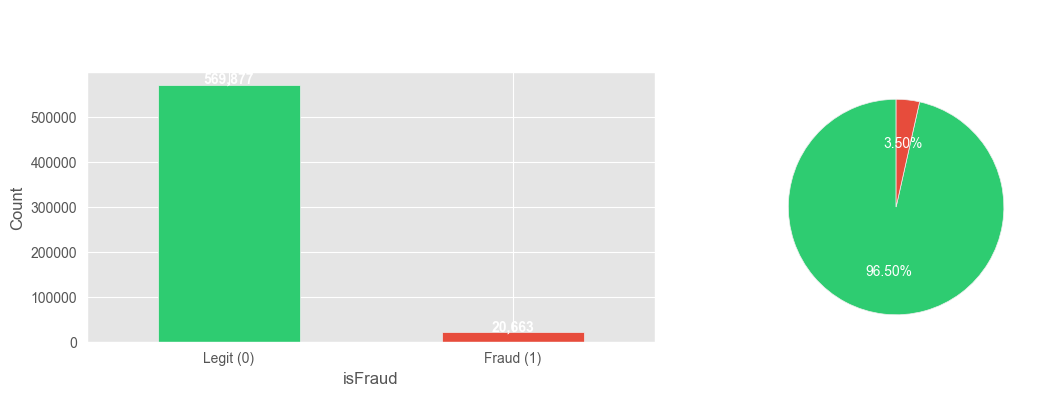

In [8]:
# Target distribution
fraud_counts = train['isFraud'].value_counts()
fraud_pct = train['isFraud'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
fraud_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie([1 - fraud_pct, fraud_pct], labels=['Legit', 'Fraud'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Fraud Ratio')

plt.suptitle(f'Target Distribution — {fraud_pct:.2%} Fraud Rate (Highly Imbalanced)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

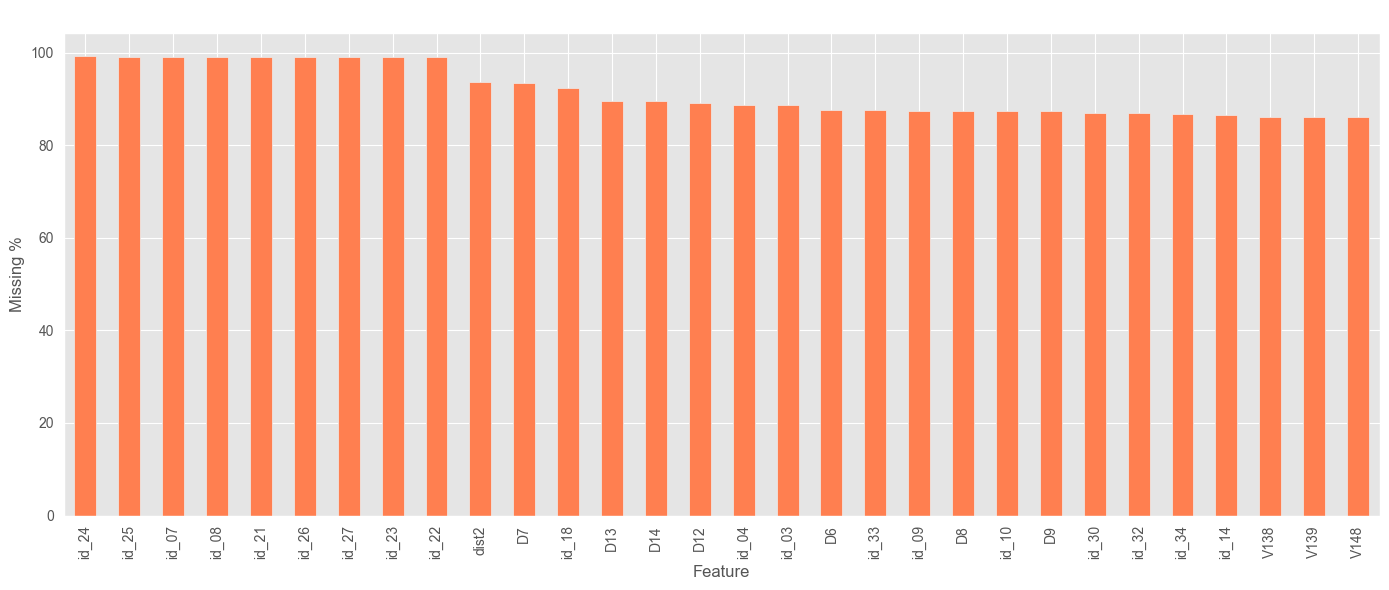


Columns with >50% missing: 214
Columns with >90% missing: 12
Columns with 0% missing:   20


In [9]:
# Missing values overview — show top 30 columns with most nulls
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).sort_values(ascending=False)
missing_top = missing_pct[missing_pct > 0].head(30)

plt.figure(figsize=(14, 6))
missing_top.plot(kind='bar', color='coral')
plt.title('Top 30 Columns by Missing Value %')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

print(f"\nColumns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 90).sum()}")
print(f"Columns with 0% missing:   {(missing_pct == 0).sum()}")

## Step 2: Exploratory Data Analysis (EDA)

Let's examine how fraud varies across the most important feature groups.

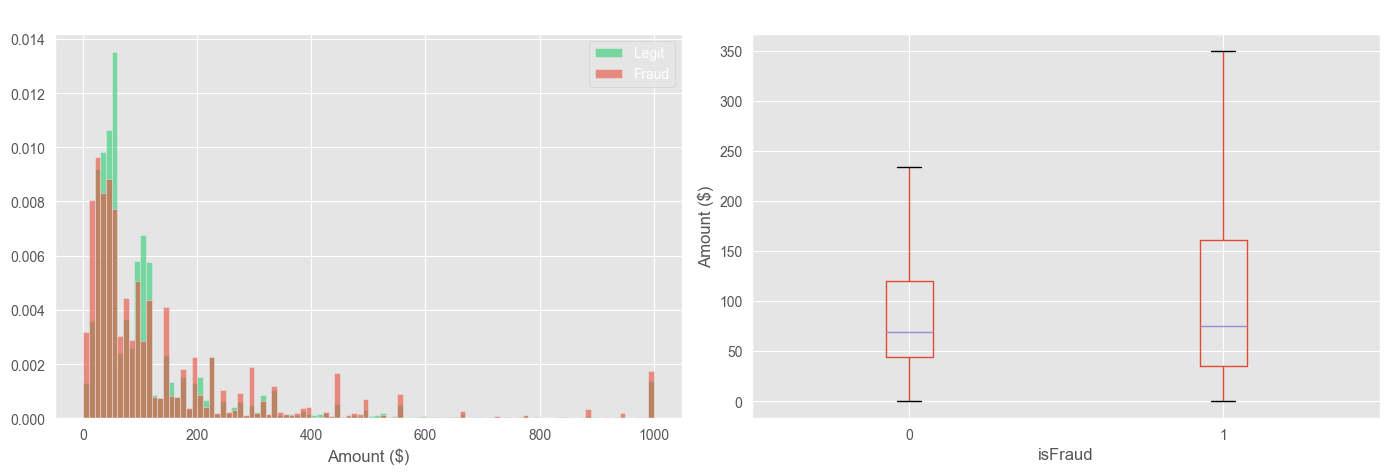

Median Transaction Amount:
isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64


In [10]:
# Transaction Amount distribution: Fraud vs Legit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
for label, color, name in [(0, '#2ecc71', 'Legit'), (1, '#e74c3c', 'Fraud')]:
    subset = train[train['isFraud'] == label]['TransactionAmt']
    axes[0].hist(subset.clip(upper=1000), bins=100, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('TransactionAmt Distribution (clipped at $1000)')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# Box plot
train.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1], showfliers=False)
axes[1].set_title('TransactionAmt by Fraud Label')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("Median Transaction Amount:")
print(train.groupby('isFraud')['TransactionAmt'].median())

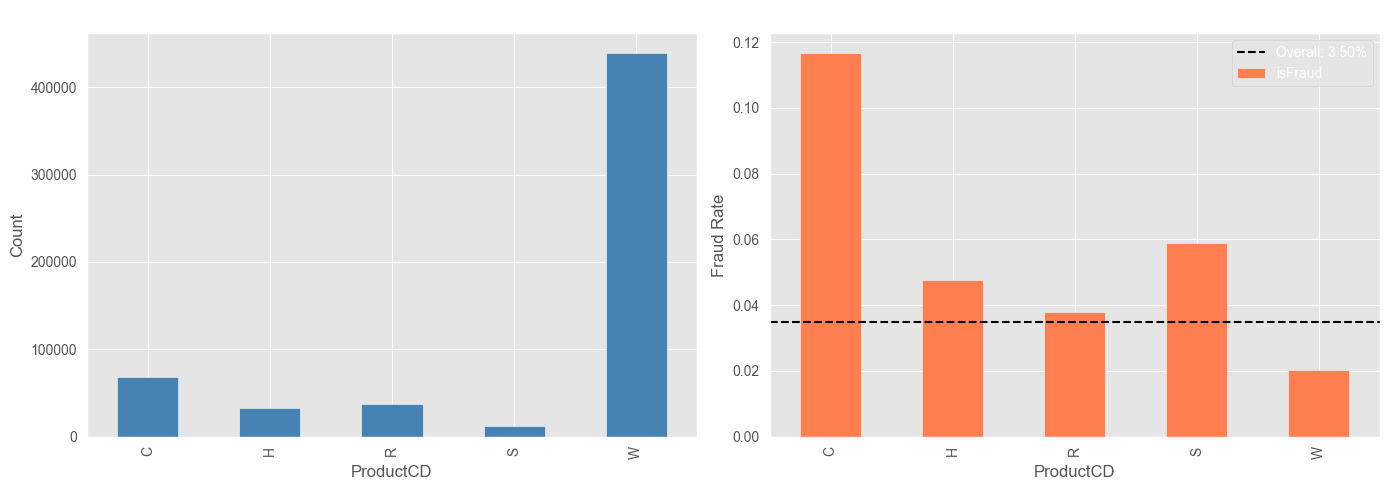

In [11]:
# ProductCD — fraud rate by product type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
train.groupby('ProductCD')['isFraud'].count().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Count by ProductCD')
axes[0].set_ylabel('Count')

# Fraud rate
train.groupby('ProductCD')['isFraud'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Fraud Rate by ProductCD')
axes[1].set_ylabel('Fraud Rate')
axes[1].axhline(y=fraud_pct, color='black', linestyle='--', label=f'Overall: {fraud_pct:.2%}')
axes[1].legend()

plt.tight_layout()
plt.show()

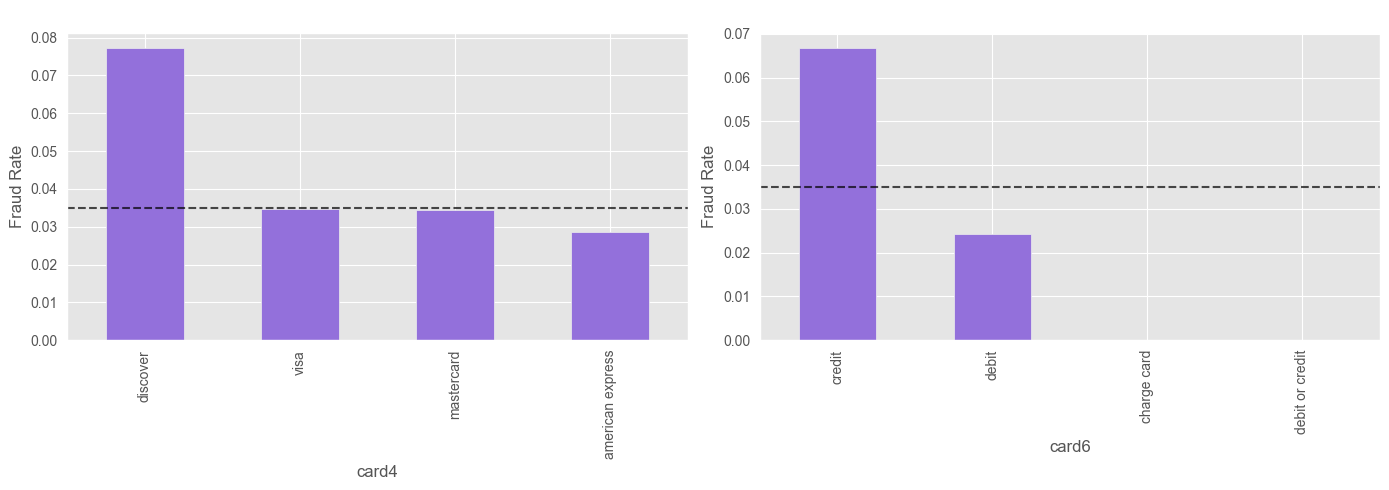

In [12]:
# Card features — fraud rate by card4 (brand) and card6 (type)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['card4', 'card6']):
    fraud_rate = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=axes[i], color='mediumpurple')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].axhline(y=fraud_pct, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

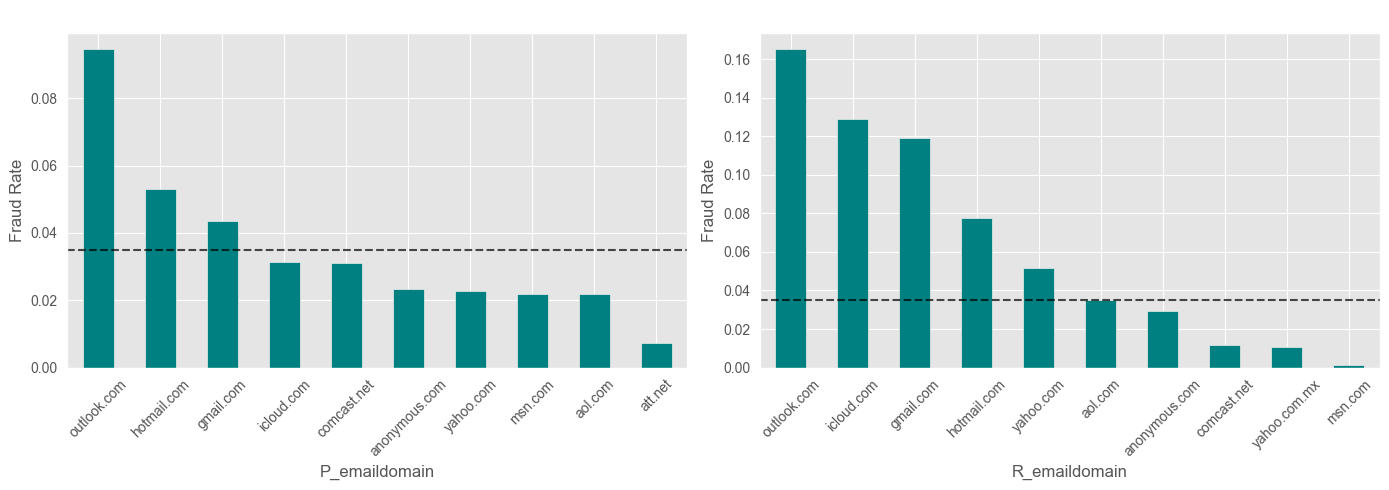

In [13]:
# Email domains — top 10 purchaser email domains by fraud rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['P_emaildomain', 'R_emaildomain']):
    top_domains = train[col].value_counts().head(10).index
    subset = train[train[col].isin(top_domains)]
    fraud_by_domain = subset.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    fraud_by_domain.plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Fraud Rate — Top 10 {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].axhline(y=fraud_pct, color='black', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

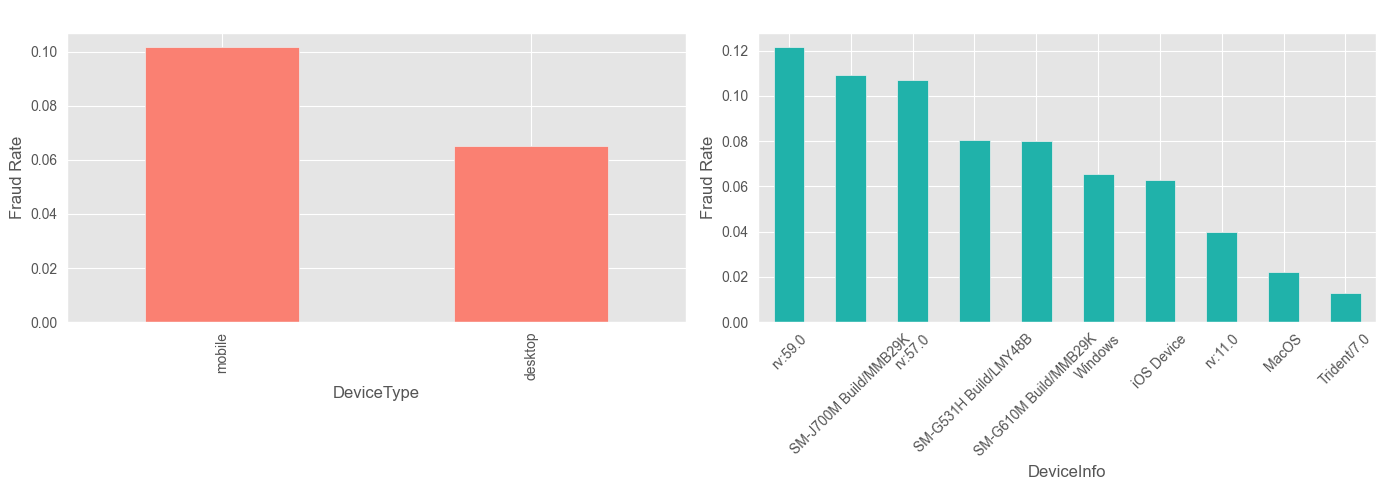

In [14]:
# DeviceType and DeviceInfo — fraud patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device Type
dt_fraud = train.groupby('DeviceType')['isFraud'].mean().sort_values(ascending=False)
dt_fraud.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Fraud Rate by DeviceType')
axes[0].set_ylabel('Fraud Rate')

# Top 10 Device Info
top_devices = train['DeviceInfo'].value_counts().head(10).index
dev_fraud = train[train['DeviceInfo'].isin(top_devices)].groupby('DeviceInfo')['isFraud'].mean().sort_values(ascending=False)
dev_fraud.plot(kind='bar', ax=axes[1], color='lightseagreen')
axes[1].set_title('Fraud Rate — Top 10 Devices')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

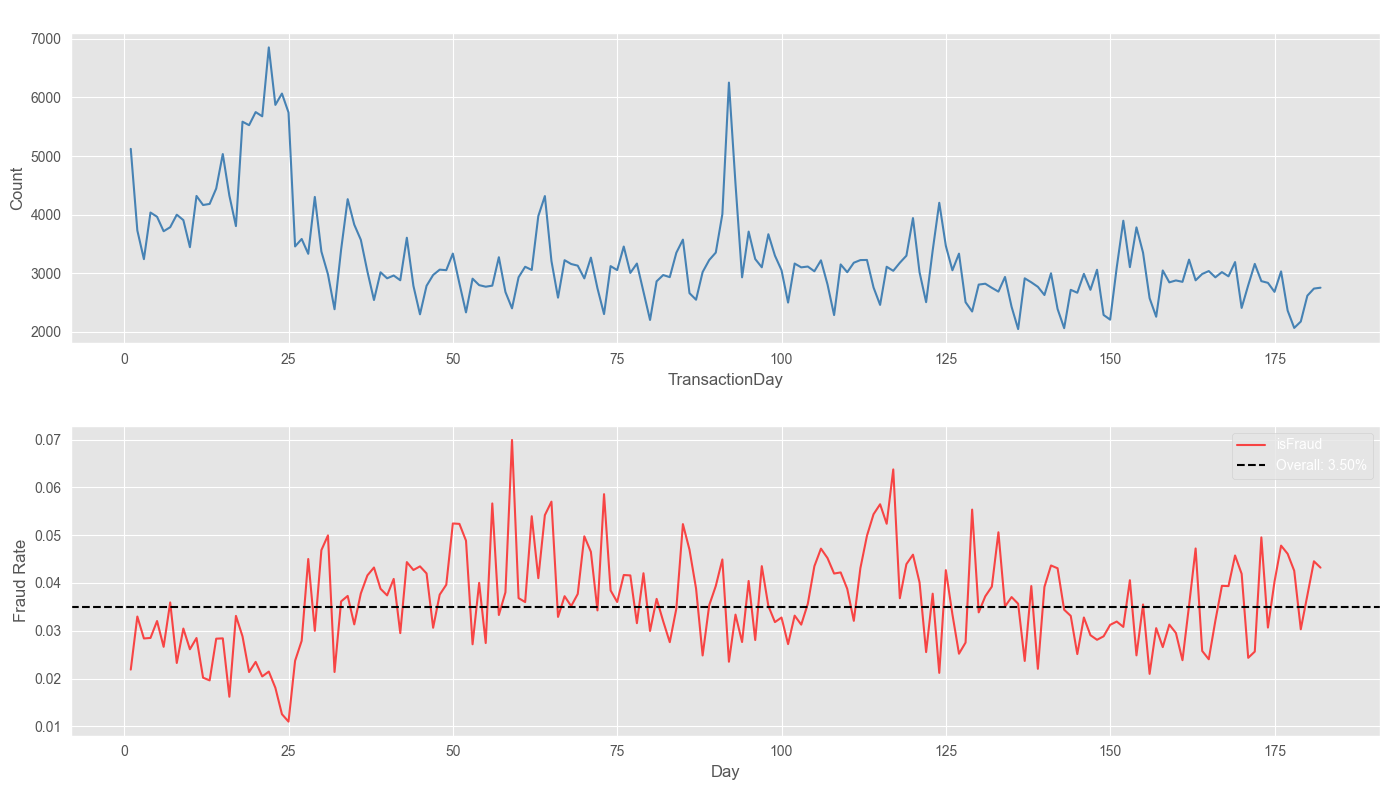

In [15]:
# Time-based analysis — fraud over time
# TransactionDT is in seconds from a reference point
train['TransactionDay'] = train['TransactionDT'] // (24 * 3600)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transaction volume over time
train.groupby('TransactionDay').size().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Daily Transaction Volume')
axes[0].set_ylabel('Count')

# Fraud rate over time
train.groupby('TransactionDay')['isFraud'].mean().plot(ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Daily Fraud Rate Over Time')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xlabel('Day')
axes[1].axhline(y=fraud_pct, color='black', linestyle='--', label=f'Overall: {fraud_pct:.2%}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 3: Feature Engineering & Preprocessing

**Strategy:**
1. **Drop columns with >90% missing** — they add noise, not signal
2. **Create time features** — hour of day, day of week from TransactionDT
3. **Transaction amount features** — log transform, decimal part (cents) as a feature
4. **Encode categoricals** — Label encoding (LightGBM handles this natively)
5. **Reduce memory** — Downcast numeric types to save RAM

In [16]:
# 1. Drop columns with >90% missing values
threshold = 0.9
missing_train = train.isnull().mean()
cols_to_drop = missing_train[missing_train > threshold].index.tolist()
# Don't drop the target
cols_to_drop = [c for c in cols_to_drop if c != 'isFraud']

print(f"Dropping {len(cols_to_drop)} columns with >{threshold*100:.0f}% missing values")
print(f"Examples: {cols_to_drop[:10]}")

train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=[c for c in cols_to_drop if c in test.columns], inplace=True)

print(f"\nRemaining shape — Train: {train.shape}, Test: {test.shape}")

Dropping 12 columns with >90% missing values
Examples: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25']

Remaining shape — Train: (590540, 423), Test: (506691, 421)


In [17]:
# 2. Time features from TransactionDT
# Reference: TransactionDT is seconds from a reference point
# The competition started around 2017-12, so we assume reference is ~2017-11-30
START_DATE = '2017-12-01'
import datetime

for df in [train, test]:
    # Convert to datetime-like features
    df['TransactionHour'] = (df['TransactionDT'] // 3600) % 24
    df['TransactionDayOfWeek'] = (df['TransactionDT'] // (3600 * 24)) % 7
    
    # 3. Transaction amount features
    df['TransactionAmt_Log'] = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_Decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)
    # Cents == 0 might indicate round dollar amounts (gift cards, fraud pattern)
    df['TransactionAmt_IsRound'] = (df['TransactionAmt'] == df['TransactionAmt'].astype(int)).astype(int)

print("New features created: TransactionHour, TransactionDayOfWeek, TransactionAmt_Log, TransactionAmt_Decimal, TransactionAmt_IsRound")
print(f"Train shape: {train.shape}")

New features created: TransactionHour, TransactionDayOfWeek, TransactionAmt_Log, TransactionAmt_Decimal, TransactionAmt_IsRound
Train shape: (590540, 428)


In [18]:
# 4. Label encode categorical features
# LightGBM can handle categoricals, but we need them as integers
from sklearn.preprocessing import LabelEncoder

# Only encode columns present in BOTH train and test
common_cols = train.columns.intersection(test.columns)
categorical_cols = train[common_cols].select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Combine train+test to fit encoder, handle NaN as a category
    combined = pd.concat([train[col].astype(str), test[col].astype(str)])
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le

# Drop any remaining object columns not in both datasets
for df in [train, test]:
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    if obj_cols:
        print(f"Dropping {len(obj_cols)} extra object columns not in both sets: {obj_cols}")
        df.drop(columns=obj_cols, inplace=True)

print(f"\nEncoded {len(categorical_cols)} categorical columns")
print(f"Train dtypes: {train.dtypes.value_counts().to_dict()}")

Categorical columns (29): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Encoded 29 categorical columns
Train dtypes: {dtype('float64'): 390, dtype('int64'): 38}


In [19]:
# 5. Reduce memory usage
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory: {start_mem:.1f} MB → {end_mem:.1f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Memory: 1928.3 MB → 906.7 MB (53.0% reduction)
Memory: 1646.8 MB → 776.5 MB (52.8% reduction)


## Step 4: Model Training — LightGBM

**Why LightGBM?**
- Handles missing values natively (no imputation needed)
- Fast training on large datasets with many features
- Built-in support for categorical features
- Excellent performance on tabular data & Kaggle competitions

**Validation Strategy**: Time-based split — we use the last 20% of transactions (by time) as validation. This mimics real-world deployment where we predict future fraud using past data.

In [20]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Prepare features and target — use only columns present in BOTH train and test
target = 'isFraud'
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionDay']
common_cols = train.columns.intersection(test.columns)
features = [c for c in common_cols if c not in drop_cols]

X = train[features]
y = train[target]
X_test = test[features]

print(f"Features: {len(features)}")
print(f"Train size: {X.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

# Time-based split: use TransactionDT ordering (data is already sorted by time)
split_idx = int(len(train) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain split: {X_train.shape[0]:,} | Val split: {X_val.shape[0]:,}")
print(f"Train fraud rate: {y_train.mean():.4f} | Val fraud rate: {y_val.mean():.4f}")

Features: 424
Train size: 590,540
Test size:  506,691

Train split: 472,432 | Val split: 118,108
Train fraud rate: 0.0351 | Val fraud rate: 0.0344


In [21]:
# Train LightGBM
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 256,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'n_jobs': -1,
    'verbose': -1,
    'is_unbalance': True,  # Handles class imbalance
    'random_state': 42
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC: {model.best_score['valid']['auc']:.6f}")

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.990426	valid's auc: 0.914138
Early stopping, best iteration is:
[111]	train's auc: 0.992008	valid's auc: 0.914258

Best iteration: 111
Best validation AUC: 0.914258


## Step 5: Evaluation & Submission

Validation AUC-ROC: 0.914258

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

       Legit       0.99      0.94      0.96    114044
       Fraud       0.29      0.66      0.41      4064

    accuracy                           0.93    118108
   macro avg       0.64      0.80      0.69    118108
weighted avg       0.96      0.93      0.95    118108



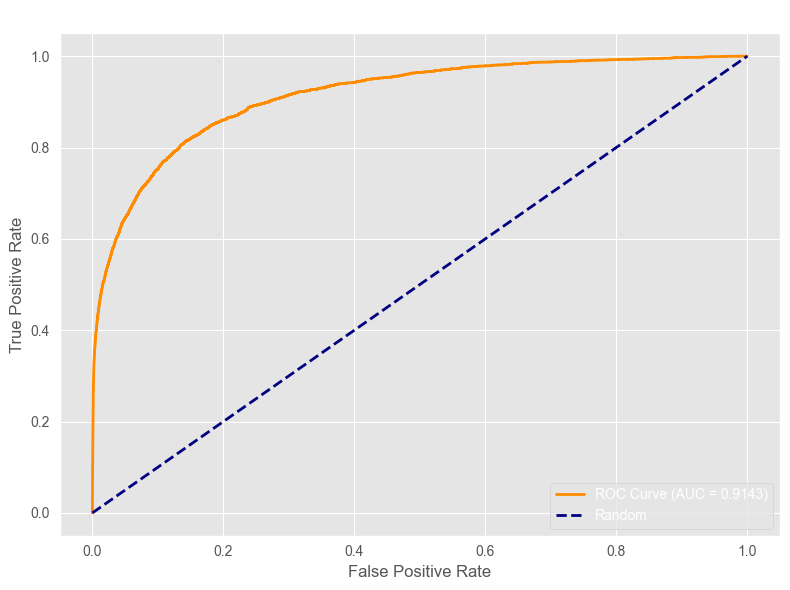

In [23]:
# Validation predictions & metrics
y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)
val_auc = roc_auc_score(y_val, y_val_pred)

print(f"Validation AUC-ROC: {val_auc:.6f}")
print(f"\nClassification Report (threshold=0.5):")
print(classification_report(y_val, (y_val_pred > 0.5).astype(int), target_names=['Legit', 'Fraud']))

# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Validation Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

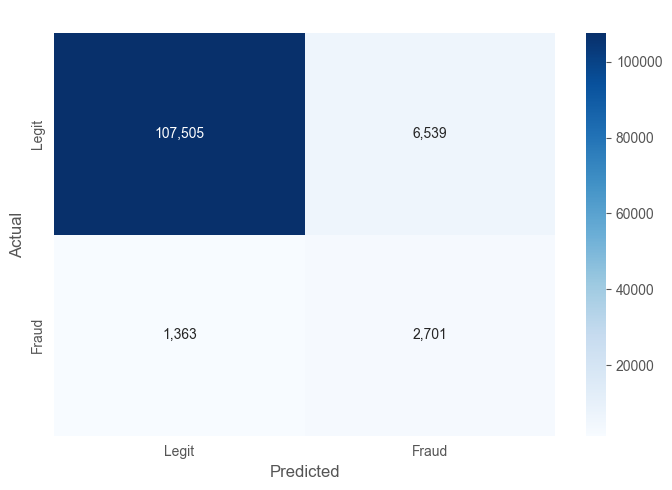

True Negatives:  107,505
False Positives: 6,539
False Negatives: 1,363
True Positives:  2,701


In [24]:
# Confusion Matrix
cm = confusion_matrix(y_val, (y_val_pred > 0.5).astype(int))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.show()

print(f"True Negatives:  {cm[0][0]:,}")
print(f"False Positives: {cm[0][1]:,}")
print(f"False Negatives: {cm[1][0]:,}")
print(f"True Positives:  {cm[1][1]:,}")

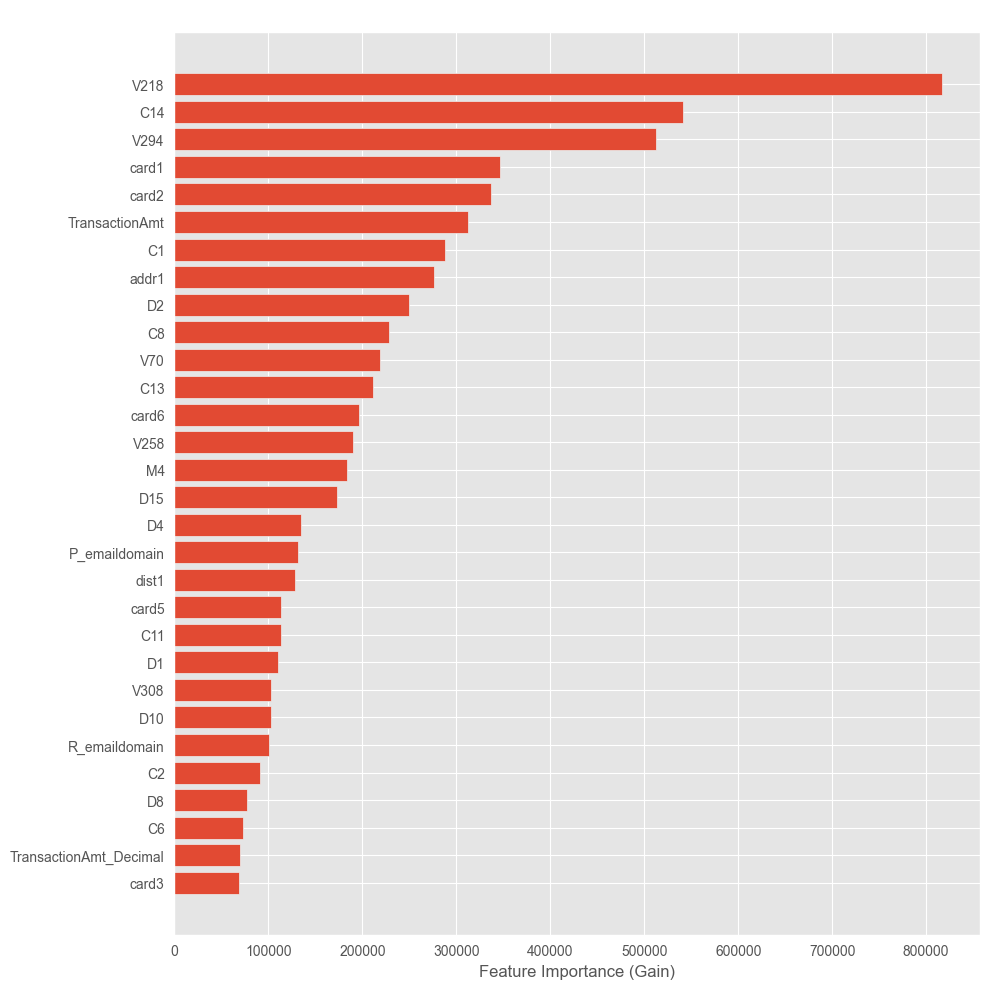


Top 15 features:
       feature    importance
          V218 816540.610596
           C14 541301.102543
          V294 512601.548954
         card1 346212.209652
         card2 336456.791958
TransactionAmt 312915.932114
            C1 288243.303577
         addr1 276615.276115
            D2 249611.556545
            C8 227915.446228
           V70 218418.402702
           C13 211776.047215
         card6 195922.293083
          V258 190215.864746
            M4 183594.875900


In [25]:
# Feature Importance — Top 30
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
top_n = 30
plt.barh(range(top_n), importance['importance'].values[:top_n][::-1])
plt.yticks(range(top_n), importance['feature'].values[:top_n][::-1])
plt.xlabel('Feature Importance (Gain)')
plt.title(f'Top {top_n} Most Important Features')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(importance.head(15).to_string(index=False))

Submission saved: submission.csv
Shape: (506691, 2)

Prediction distribution:
count    506691.000000
mean          0.143043
std           0.201864
min           0.000675
25%           0.023321
50%           0.057135
75%           0.166963
max           0.994352
Name: isFraud, dtype: float64


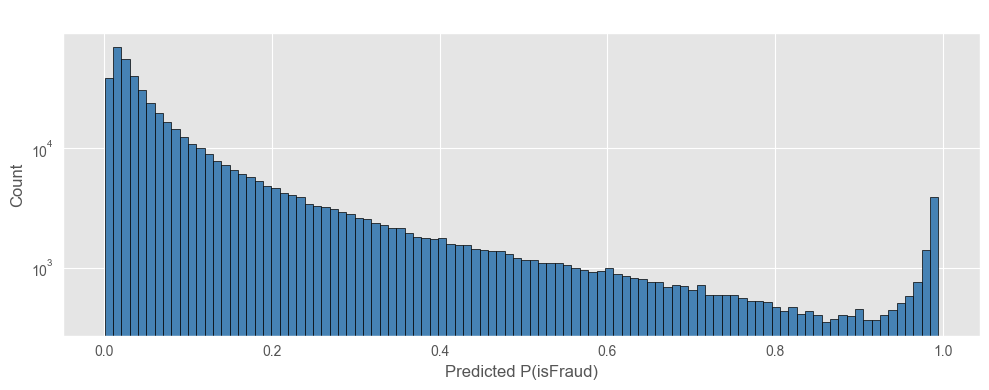

In [26]:
# Generate submission file
test_pred = model.predict(X_test, num_iteration=model.best_iteration)

submission = pd.read_csv(DATA_DIR + 'sample_submission.csv')
submission['isFraud'] = test_pred

submission.to_csv('submission.csv', index=False)
print(f"Submission saved: submission.csv")
print(f"Shape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['isFraud'].describe())

plt.figure(figsize=(10, 4))
plt.hist(submission['isFraud'], bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Predicted Fraud Probabilities')
plt.xlabel('Predicted P(isFraud)')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.show()

## Summary & Key Findings

### Approach
1. **Merged** transaction + identity tables via LEFT JOIN (~24% of transactions have identity info)
2. **Dropped** columns with >90% missing values to reduce noise
3. **Engineered features**: hour of day, day of week, log amount, decimal cents, round-dollar flag
4. **Label encoded** categorical features (LightGBM handles them natively)
5. **Reduced memory** via numeric downcasting
6. **Trained LightGBM** with time-based 80/20 split, early stopping, and `is_unbalance=True` for class imbalance

### Why These Choices?
- **Time-based split** prevents data leakage — in production, you only have past data to predict future fraud
- **LightGBM** handles missing values, categoricals, and imbalanced classes out of the box
- **No imputation needed** — tree-based models learn optimal split directions for missing values
- **`is_unbalance=True`** adjusts sample weights to handle the ~3.5% fraud rate

### Potential Improvements
- **K-Fold cross-validation** (time-series aware) for more robust estimates
- **Feature selection** — remove low-importance V columns to reduce overfitting
- **Aggregation features** — mean/count of TransactionAmt per card1, per email domain, etc.
- **Ensemble** — blend LightGBM + XGBoost + CatBoost for a few extra AUC points
- **Hyperparameter tuning** — Optuna/Bayesian optimization on key params